# Linear Regression Homework


In [18]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

np.random.seed(42)

# Set matplotlib to display plots inline
%matplotlib inline

## Load and Prepare the Dataset

In [19]:
# Load California Housing dataset
california = fetch_california_housing()
X_raw = pd.DataFrame(california.data, columns=california.feature_names)
y_raw = pd.Series(california.target, name='Price')

print(f"Dataset shape: {X_raw.shape}")
print(f"\nFeatures: {list(X_raw.columns)}")
print(f"\nFirst 5 rows:")
print(X_raw.head())
print(f"\nTarget (Price in $100,000s):")
print(y_raw.head())
print(f"\nBasic statistics:")
print(X_raw.describe())

Dataset shape: (20640, 8)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Target (Price in $100,000s):
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64

Basic statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3

In [20]:
X = X_raw[['HouseAge', 'AveRooms', 'AveBedrms']].values
y = y_raw.values

# Add bias term (column of ones)
m = len(y)
X_bias = np.column_stack([np.ones(m), X])

print(f"Feature matrix shape: {X_bias.shape}")
print(f"\nFeatures used: ['Bias', 'HouseAge', 'AveRooms', 'AveBedrms']")
print(f"\nFirst 5 samples (with bias):")
print(X_bias[:5])
print(f"\nTarget statistics:")
print(f"  Min: ${y.min()*100000:,.0f}")
print(f"  Max: ${y.max()*100000:,.0f}")
print(f"  Mean: ${y.mean()*100000:,.0f}")
print(f"  Median: ${np.median(y)*100000:,.0f}")

Feature matrix shape: (20640, 4)

Features used: ['Bias', 'HouseAge', 'AveRooms', 'AveBedrms']

First 5 samples (with bias):
[[ 1.         41.          6.98412698  1.02380952]
 [ 1.         21.          6.23813708  0.97188049]
 [ 1.         52.          8.28813559  1.07344633]
 [ 1.         52.          5.8173516   1.07305936]
 [ 1.         52.          6.28185328  1.08108108]]

Target statistics:
  Min: $14,999
  Max: $500,001
  Mean: $206,856
  Median: $179,700


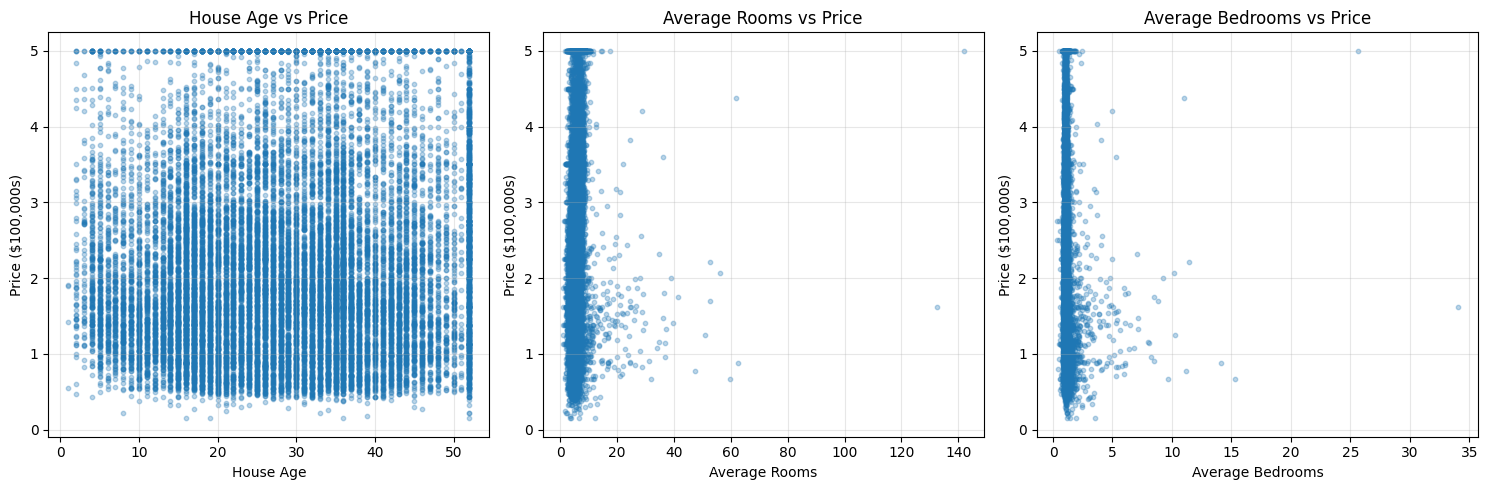

In [21]:
# Visualize the data
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(X[:, 0], y, alpha=0.3, s=10)
axes[0].set_xlabel('House Age')
axes[0].set_ylabel('Price ($100,000s)')
axes[0].set_title('House Age vs Price')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X[:, 1], y, alpha=0.3, s=10)
axes[1].set_xlabel('Average Rooms')
axes[1].set_ylabel('Price ($100,000s)')
axes[1].set_title('Average Rooms vs Price')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(X[:, 2], y, alpha=0.3, s=10)
axes[2].set_xlabel('Average Bedrooms')
axes[2].set_ylabel('Price ($100,000s)')
axes[2].set_title('Average Bedrooms vs Price')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
def hypothesis(X, w):
    """
    Compute the hypothesis function in vector form.
    
    Parameters:
    X : numpy array of shape (m, n) - feature matrix with bias
    w : numpy array of shape (n,) - weight vector
    
    Returns:
    numpy array of shape (m,) - predicted values
    """
    return X @ w

# Test the hypothesis function
X_test = np.array([[1, 10, 5, 2],
                   [1, 20, 6, 3]])
w_test = np.array([0.5, 0.1, 0.2, 0.3])
print(f"Test X shape: {X_test.shape}")
print(f"Test w shape: {w_test.shape}")
print(f"Hypothesis result: {hypothesis(X_test, w_test)}")
print(f"Expected: [10*0.1 + 5*0.2 + 2*0.3 + 0.5, 20*0.1 + 6*0.2 + 3*0.3 + 0.5] = [2.6, 4.6]")

Test X shape: (2, 4)
Test w shape: (4,)
Hypothesis result: [3.1 4.6]
Expected: [10*0.1 + 5*0.2 + 2*0.3 + 0.5, 20*0.1 + 6*0.2 + 3*0.3 + 0.5] = [2.6, 4.6]


---
## 2. Loss Function (Vector Form)


In [23]:
def loss_function(X, y, w):
    """
    Compute the MSE loss function in vector form.
    
    Parameters:
    X : numpy array of shape (m, n) - feature matrix with bias
    y : numpy array of shape (m,) - target values
    w : numpy array of shape (n,) - weight vector
    
    Returns:
    float - MSE loss value
    """
    m = len(y)
    error = hypothesis(X, w) - y
    return (1 / (2 * m)) * (error @ error)

# Test the loss function
y_test = np.array([3.0, 5.0])
loss = loss_function(X_test, y_test, w_test)
print(f"Test predictions: {hypothesis(X_test, w_test)}")
print(f"Test actual: {y_test}")
print(f"Loss: {loss:.4f}")

Test predictions: [3.1 4.6]
Test actual: [3. 5.]
Loss: 0.0425


---
## 3. Gradient Descent Step

In [24]:
def gradient_descent_step(X, y, w, alpha):
    """
    Perform one step of gradient descent.
    
    Parameters:
    X : numpy array of shape (m, n) - feature matrix with bias
    y : numpy array of shape (m,) - target values
    w : numpy array of shape (n,) - current weight vector
    alpha : float - learning rate
    
    Returns:
    tuple: (updated_weights, gradient)
    """
    m = len(y)
    error = hypothesis(X, w) - y
    gradient = (1 / m) * (X.T @ error)
    w_updated = w - alpha * gradient
    return w_updated, gradient

# Test gradient descent step
w_new, grad = gradient_descent_step(X_test, y_test, w_test, alpha=0.01)
print(f"Initial weights: {w_test}")
print(f"Gradient: {grad}")
print(f"Updated weights: {w_new}")
print(f"Loss before: {loss_function(X_test, y_test, w_test):.4f}")
print(f"Loss after: {loss_function(X_test, y_test, w_new):.4f}")

Initial weights: [0.5 0.1 0.2 0.3]
Gradient: [-0.15 -3.5  -0.95 -0.5 ]
Updated weights: [0.5015 0.135  0.2095 0.305 ]
Loss before: 0.0425
Loss after: 0.0996


---
## 4. Finding Optimal Parameters Using Gradient Descent

In [25]:
# Scale features for better gradient descent convergence
scaler = StandardScaler()
X_scaled_features = scaler.fit_transform(X)
X_scaled = np.column_stack([np.ones(m), X_scaled_features])

print(f"Scaled features shape: {X_scaled.shape}")
print(f"\nFeature means (should be ~0): {X_scaled[:, 1:].mean(axis=0)}")
print(f"Feature stds (should be ~1): {X_scaled[:, 1:].std(axis=0)}")

Scaled features shape: (20640, 4)

Feature means (should be ~0): [ 4.40646658e-17  7.71131651e-17 -1.00522519e-16]
Feature stds (should be ~1): [1. 1. 1.]


In [26]:
def train_gradient_descent(X, y, alpha=0.1, iterations=1000):
    """
    Train linear regression using gradient descent.
    
    Parameters:
    X : numpy array of shape (m, n) - feature matrix with bias
    y : numpy array of shape (m,) - target values
    alpha : float - learning rate
    iterations : int - number of iterations
    
    Returns:
    tuple: (optimal_weights, loss_history)
    """
    n = X.shape[1]
    w = np.zeros(n)
    loss_history = []
    
    for i in range(iterations):
        w, gradient = gradient_descent_step(X, y, w, alpha)
        loss = loss_function(X, y, w)
        loss_history.append(loss)
        
        if i % 100 == 0:
            print(f"Iteration {i:>4d}, Loss: {loss:.6f}")
    
    return w, loss_history

# Train with gradient descent
print("Training with Gradient Descent...\n")
alpha = 0.1
iterations = 1000
w_gd, loss_history = train_gradient_descent(X_scaled, y, alpha=alpha, iterations=iterations)

print(f"\n{'='*50}")
print(f"Optimal weights (Gradient Descent):")
print(f"  Bias:        {w_gd[0]:.4f}")
print(f"  HouseAge:    {w_gd[1]:.4f}")
print(f"  AveRooms:    {w_gd[2]:.4f}")
print(f"  AveBedrms:   {w_gd[3]:.4f}")

Training with Gradient Descent...

Iteration    0, Loss: 2.394028
Iteration  100, Loss: 0.564307
Iteration  200, Loss: 0.559858
Iteration  300, Loss: 0.559637
Iteration  400, Loss: 0.559626
Iteration  500, Loss: 0.559626
Iteration  600, Loss: 0.559626
Iteration  700, Loss: 0.559626
Iteration  800, Loss: 0.559626
Iteration  900, Loss: 0.559626

Optimal weights (Gradient Descent):
  Bias:        2.0686
  HouseAge:    0.1927
  AveRooms:    0.8448
  AveBedrms:   -0.7550


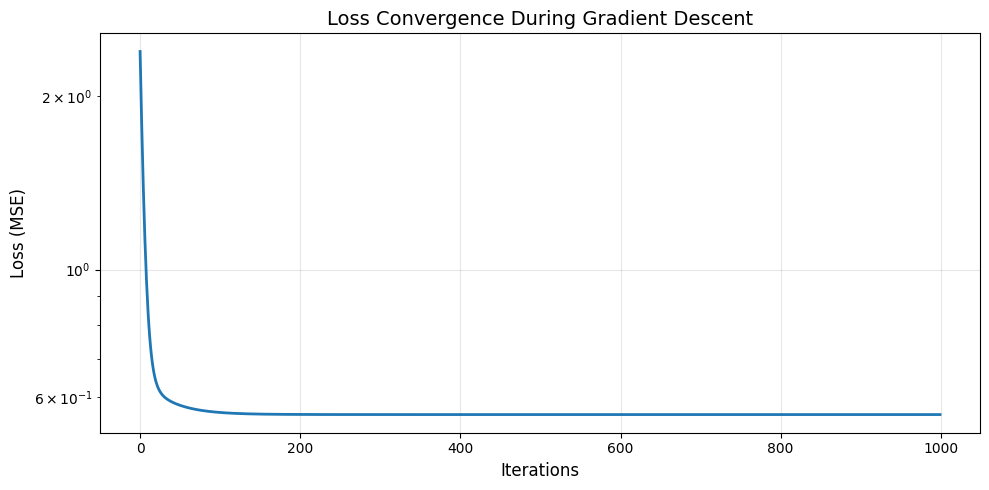

Initial loss: 2.3940
Final loss: 0.5596


In [27]:
# Plot loss convergence
plt.figure(figsize=(10, 5))
plt.plot(loss_history, linewidth=2)
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Loss Convergence During Gradient Descent', fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

print(f"Initial loss: {loss_history[0]:.4f}")
print(f"Final loss: {loss_history[-1]:.4f}")

---
## 5. Analytical Solution (Normal Equation)

In [28]:
def analytical_solution(X, y):
    """
    Compute optimal weights using the normal equation.
    
    Parameters:
    X : numpy array of shape (m, n) - feature matrix with bias
    y : numpy array of shape (m,) - target values
    
    Returns:
    numpy array of shape (n,) - optimal weight vector
    """
    return np.linalg.inv(X.T @ X) @ X.T @ y

# Compute analytical solution
print("Computing Analytical Solution...\n")
w_analytical = analytical_solution(X_scaled, y)

print(f"{'='*50}")
print(f"Optimal weights (Analytical Solution):")
print(f"  Bias:        {w_analytical[0]:.4f}")
print(f"  HouseAge:    {w_analytical[1]:.4f}")
print(f"  AveRooms:    {w_analytical[2]:.4f}")
print(f"  AveBedrms:   {w_analytical[3]:.4f}")

Computing Analytical Solution...

Optimal weights (Analytical Solution):
  Bias:        2.0686
  HouseAge:    0.1927
  AveRooms:    0.8448
  AveBedrms:   -0.7550


In [29]:
# Compare Gradient Descent vs Analytical Solution
print(f"{'='*70}")
print(f"{'Parameter':<15} {'Gradient Descent':<20} {'Analytical':<20} {'Difference':<15}")
print(f"{'='*70}")
feature_names = ['Bias', 'HouseAge', 'AveRooms', 'AveBedrms']
for i, name in enumerate(feature_names):
    diff = abs(w_gd[i] - w_analytical[i])
    print(f"{name:<15} {w_gd[i]:<20.6f} {w_analytical[i]:<20.6f} {diff:<15.6f}")
print(f"{'='*70}")

Parameter       Gradient Descent     Analytical           Difference     
Bias            2.068558             2.068558             0.000000       
HouseAge        0.192675             0.192675             0.000000       
AveRooms        0.844824             0.844825             0.000000       
AveBedrms       -0.755000            -0.755000            0.000000       


---
## 6. Comparison with Scikit-Learn's LinearRegression

In [30]:
# Train scikit-learn LinearRegression
print("Training Scikit-Learn LinearRegression...\n")
lr = LinearRegression()
lr.fit(X_scaled[:, 1:], y)  # Exclude bias column

# Combine intercept and coefficients
w_sklearn = np.concatenate([[lr.intercept_], lr.coef_])

print(f"{'='*50}")
print(f"Optimal weights (Scikit-Learn):")
print(f"  Bias (intercept):  {w_sklearn[0]:.4f}")
print(f"  HouseAge:          {w_sklearn[1]:.4f}")
print(f"  AveRooms:          {w_sklearn[2]:.4f}")
print(f"  AveBedrms:         {w_sklearn[3]:.4f}")

Training Scikit-Learn LinearRegression...

Optimal weights (Scikit-Learn):
  Bias (intercept):  2.0686
  HouseAge:          0.1927
  AveRooms:          0.8448
  AveBedrms:         -0.7550


In [31]:
# Final comparison of all three methods
print(f"\n{'='*85}")
print(f"{'Parameter':<15} {'Gradient Descent':<22} {'Analytical':<22} {'Scikit-Learn':<22}")
print(f"{'='*85}")
for i, name in enumerate(feature_names):
    print(f"{name:<15} {w_gd[i]:<22.6f} {w_analytical[i]:<22.6f} {w_sklearn[i]:<22.6f}")
print(f"{'='*85}")


Parameter       Gradient Descent       Analytical             Scikit-Learn          
Bias            2.068558               2.068558               2.068558              
HouseAge        0.192675               0.192675               0.192675              
AveRooms        0.844824               0.844825               0.844825              
AveBedrms       -0.755000              -0.755000              -0.755000             


In [32]:
# Calculate and compare MSE and R² scores
y_pred_gd = hypothesis(X_scaled, w_gd)
y_pred_analytical = hypothesis(X_scaled, w_analytical)
y_pred_sklearn = lr.predict(X_scaled[:, 1:])

# MSE calculations
mse_gd = np.mean((y - y_pred_gd) ** 2)
mse_analytical = np.mean((y - y_pred_analytical) ** 2)
mse_sklearn = np.mean((y - y_pred_sklearn) ** 2)

# R² calculations
ss_res_gd = np.sum((y - y_pred_gd) ** 2)
ss_res_analytical = np.sum((y - y_pred_analytical) ** 2)
ss_res_sklearn = np.sum((y - y_pred_sklearn) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)

r2_gd = 1 - (ss_res_gd / ss_tot)
r2_analytical = 1 - (ss_res_analytical / ss_tot)
r2_sklearn = lr.score(X_scaled[:, 1:], y)

print(f"{'='*85}")
print(f"{'Metric':<20} {'Gradient Descent':<22} {'Analytical':<22} {'Scikit-Learn':<22}")
print(f"{'='*85}")
print(f"{'MSE':<20} {mse_gd:<22.6f} {mse_analytical:<22.6f} {mse_sklearn:<22.6f}")
print(f"{'R² Score':<20} {r2_gd:<22.6f} {r2_analytical:<22.6f} {r2_sklearn:<22.6f}")
print(f"{'='*85}")

Metric               Gradient Descent       Analytical             Scikit-Learn          
MSE                  1.119251               1.119251               1.119251              
R² Score             0.159438               0.159438               0.159438              


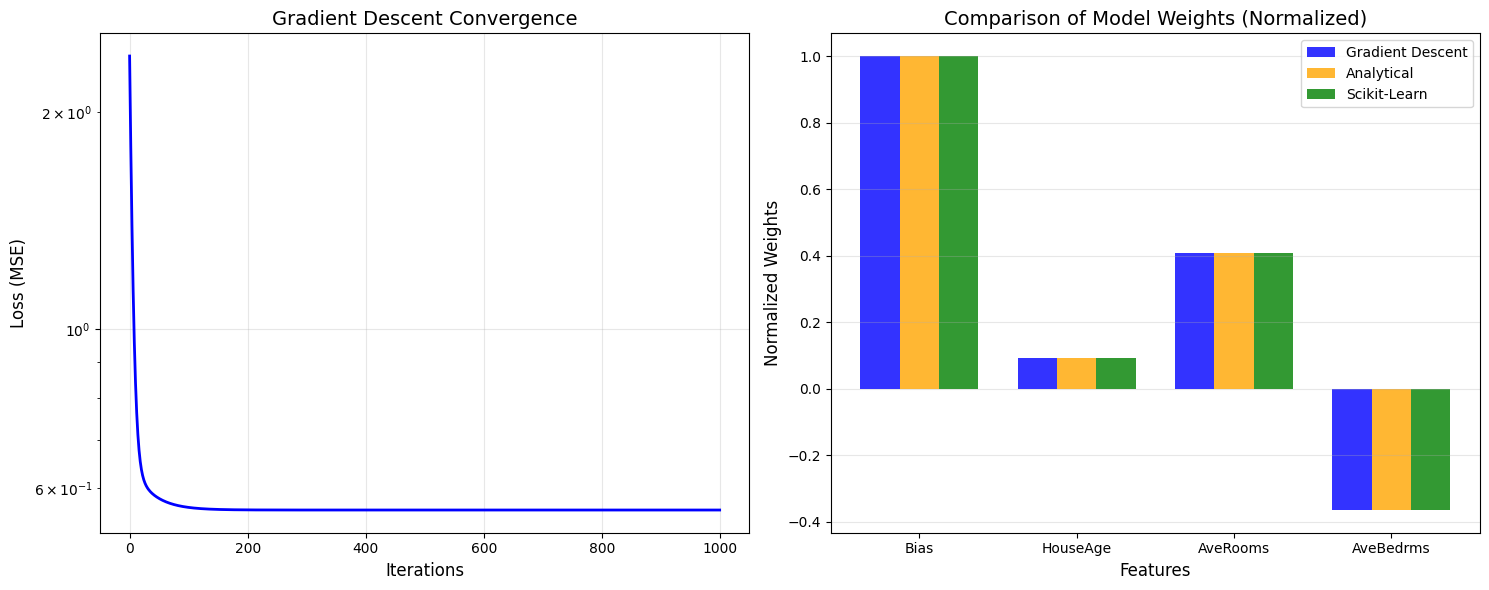

In [33]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Loss convergence
axes[0].plot(loss_history, linewidth=2, color='blue')
axes[0].set_xlabel('Iterations', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Gradient Descent Convergence', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot 2: Weight comparison (normalized)
w_gd_norm = w_gd / np.max(np.abs(w_gd))
w_analytical_norm = w_analytical / np.max(np.abs(w_analytical))
w_sklearn_norm = w_sklearn / np.max(np.abs(w_sklearn))

x_pos = np.arange(len(feature_names))
width = 0.25

axes[1].bar(x_pos - width, w_gd_norm, width, label='Gradient Descent', alpha=0.8, color='blue')
axes[1].bar(x_pos, w_analytical_norm, width, label='Analytical', alpha=0.8, color='orange')
axes[1].bar(x_pos + width, w_sklearn_norm, width, label='Scikit-Learn', alpha=0.8, color='green')
axes[1].set_xlabel('Features', fontsize=12)
axes[1].set_ylabel('Normalized Weights', fontsize=12)
axes[1].set_title('Comparison of Model Weights (Normalized)', fontsize=14)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(feature_names)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## 7. Making Predictions on New Data

Let's test our models by predicting the price of a new house with specific features.

In [34]:
# Create a new house example
# HouseAge=25 years, AveRooms=5.5, AveBedrms=1.2
new_house = np.array([[25, 5.5, 1.2]])

# Scale the features
new_house_scaled = scaler.transform(new_house)
new_house_with_bias = np.column_stack([np.ones(1), new_house_scaled])

# Make predictions
pred_gd = hypothesis(new_house_with_bias, w_gd)[0]
pred_analytical = hypothesis(new_house_with_bias, w_analytical)[0]
pred_sklearn = lr.predict(new_house_scaled)[0]

print(f"{'='*60}")
print(f"New House Features:")
print(f"  House Age:      {new_house[0, 0]} years")
print(f"  Average Rooms:  {new_house[0, 1]}")
print(f"  Average Bedrms: {new_house[0, 2]}")
print(f"{'='*60}")
print(f"\nPredicted Prices ($100,000s):")
print(f"  Gradient Descent:  ${pred_gd*100000:,.0f}")
print(f"  Analytical:        ${pred_analytical*100000:,.0f}")
print(f"  Scikit-Learn:      ${pred_sklearn*100000:,.0f}")
print(f"\nDifference (max):  ${abs(pred_gd - pred_sklearn)*100000:,.0f}")

New House Features:
  House Age:      25.0 years
  Average Rooms:  5.5
  Average Bedrms: 1.2

Predicted Prices ($100,000s):
  Gradient Descent:  $187,247
  Analytical:        $187,247
  Scikit-Learn:      $187,247

Difference (max):  $0
